# 🏠 House Price Prediction — Analyse Exploratoire des Données (EDA)

> **Dataset** : Ames Housing — Kaggle Competition  
> **Auteur** : [Votre Nom]  
> **Date** : 2026  

---

## Objectif

Ce notebook réalise une **analyse exploratoire complète** du dataset Ames Housing.  
L'objectif est de comprendre la structure des données, identifier les patterns, les valeurs manquantes
et les relations entre variables avant la modélisation.

## Table des Matières

1. [Imports & Configuration](#1)
2. [Chargement & Aperçu des Données](#2)
3. [Analyse de la Variable Cible — SalePrice](#3)
4. [Analyse des Valeurs Manquantes](#4)
5. [Variables Numériques — Distributions & Corrélations](#5)
6. [Variables Catégorielles — Impact sur le Prix](#6)
7. [Matrice de Corrélation](#7)
8. [Synthèse & Insights](#8)


## 1. Imports & Configuration <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

# ── Configuration globale des graphiques
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Palette professionnelle
COLORS = ['#1E3A5F', '#2563EB', '#3B82F6', '#93C5FD', '#BFDBFE']
ACCENT = '#EF4444'
sns.set_palette(COLORS)

print('✅ Configuration OK')
print(f'   Pandas  : {pd.__version__}')
print(f'   NumPy   : {np.__version__}')


✅ Configuration OK
   Pandas  : 3.0.1
   NumPy   : 2.4.3


## 2. Chargement & Aperçu des Données <a id='2'></a>

In [2]:
# ── Chargement
train = pd.read_csv('../data/train.csv')
test  = pd.read_csv('../data/test.csv')

print('=' * 55)
print('       INFORMATIONS SUR LE DATASET')
print('=' * 55)
print(f'  Train  : {train.shape[0]:,} lignes × {train.shape[1]} colonnes')
print(f'  Test   : {test.shape[0]:,} lignes × {test.shape[1]} colonnes')
print(f'  Target : SalePrice (régression)')
print('=' * 55)

# Aperçu
train.head(5)


       INFORMATIONS SUR LE DATASET
  Train  : 1,460 lignes × 81 colonnes
  Test   : 1,459 lignes × 80 colonnes
  Target : SalePrice (régression)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Types de données
num_cols = train.select_dtypes(include=np.number).columns.tolist()
cat_cols = train.select_dtypes(include='object').columns.tolist()

print(f'Variables numériques  : {len(num_cols)}')
print(f'Variables catégorielles: {len(cat_cols)}')
print(f'Total features        : {train.shape[1] - 1} (hors SalePrice)')

# Statistiques descriptives
print('\n── Statistiques de la cible SalePrice ──')
print(train['SalePrice'].describe().round(2).to_string())


Variables numériques  : 38
Variables catégorielles: 43
Total features        : 80 (hors SalePrice)

── Statistiques de la cible SalePrice ──
count      1460.0
mean     180921.2
std       79442.5
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0


## 3. Analyse de la Variable Cible — SalePrice <a id='3'></a>

La variable cible `SalePrice` représente le prix final de vente en dollars.  
On analyse sa distribution et on vérifie l'intérêt d'une transformation logarithmique.

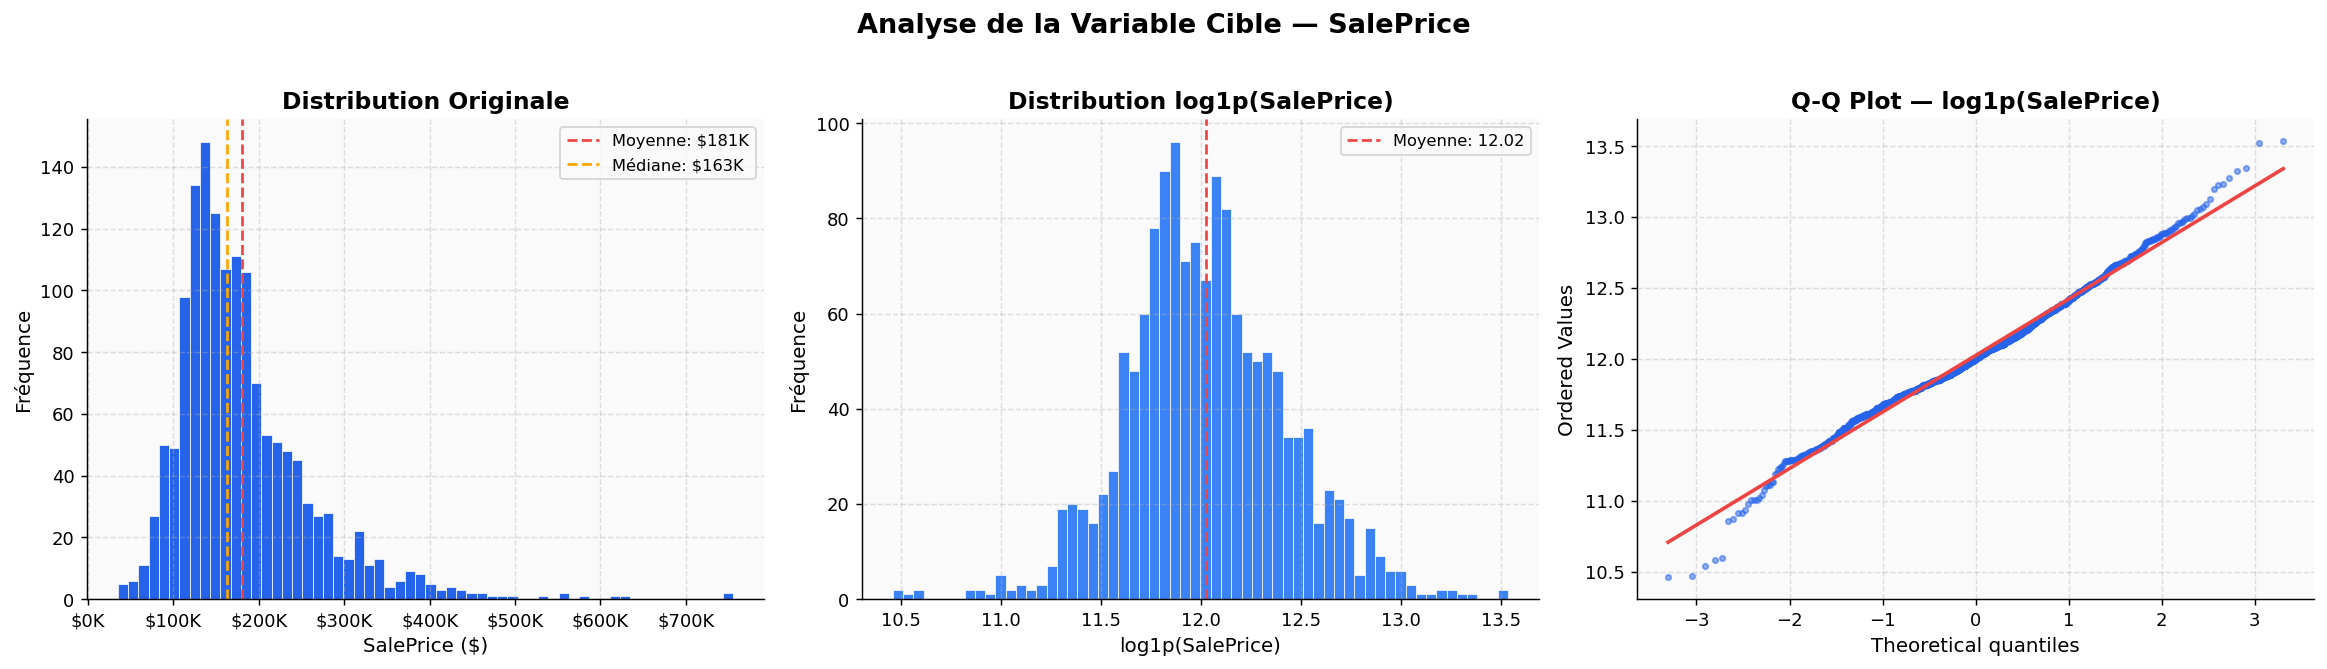

Skewness original : 1.8809  → skewed à droite
Skewness log1p    : 0.1212       → proche de la normale
Kurtosis original : 6.5098
Kurtosis log1p    : 0.8026

📌 Conclusion : Utiliser log1p(SalePrice) comme variable cible en modélisation


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Analyse de la Variable Cible — SalePrice', fontsize=15, fontweight='bold', y=1.02)

# Distribution originale
axes[0].hist(train['SalePrice'], bins=60, color=COLORS[1], edgecolor='white', linewidth=0.4)
axes[0].set_title('Distribution Originale', fontweight='bold')
axes[0].set_xlabel('SalePrice ($)')
axes[0].set_ylabel('Fréquence')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].axvline(train['SalePrice'].mean(), color=ACCENT, linestyle='--', label=f'Moyenne: ${train["SalePrice"].mean()/1000:.0f}K')
axes[0].axvline(train['SalePrice'].median(), color='orange', linestyle='--', label=f'Médiane: ${train["SalePrice"].median()/1000:.0f}K')
axes[0].legend(fontsize=9)

# Distribution log1p
log_price = np.log1p(train['SalePrice'])
axes[1].hist(log_price, bins=60, color=COLORS[2], edgecolor='white', linewidth=0.4)
axes[1].set_title('Distribution log1p(SalePrice)', fontweight='bold')
axes[1].set_xlabel('log1p(SalePrice)')
axes[1].set_ylabel('Fréquence')
axes[1].axvline(log_price.mean(), color=ACCENT, linestyle='--', label=f'Moyenne: {log_price.mean():.2f}')
axes[1].legend(fontsize=9)

# Q-Q Plot
stats.probplot(log_price, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot — log1p(SalePrice)', fontweight='bold')
axes[2].get_lines()[0].set(color=COLORS[1], markersize=3, alpha=0.5)
axes[2].get_lines()[1].set(color=ACCENT, linewidth=2)

plt.tight_layout()
plt.savefig('../data/fig_01_target_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Skewness original : {skew(train["SalePrice"]):.4f}  → skewed à droite')
print(f'Skewness log1p    : {skew(log_price):.4f}       → proche de la normale')
print(f'Kurtosis original : {kurtosis(train["SalePrice"]):.4f}')
print(f'Kurtosis log1p    : {kurtosis(log_price):.4f}')
print('\n📌 Conclusion : Utiliser log1p(SalePrice) comme variable cible en modélisation')


## 4. Analyse des Valeurs Manquantes <a id='4'></a>

In [5]:
# Calcul des valeurs manquantes
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({'Nombre': missing, 'Pourcentage (%)': missing_pct})

print(f'Colonnes avec valeurs manquantes : {len(missing_df)}')
print('\nTop 20 colonnes :')
print(missing_df.head(20).to_string())


Colonnes avec valeurs manquantes : 19

Top 20 colonnes :
              Nombre  Pourcentage (%)
PoolQC          1453            99.52
MiscFeature     1406            96.30
Alley           1369            93.77
Fence           1179            80.75
MasVnrType       872            59.73
FireplaceQu      690            47.26
LotFrontage      259            17.74
GarageType        81             5.55
GarageYrBlt       81             5.55
GarageFinish      81             5.55
GarageQual        81             5.55
GarageCond        81             5.55
BsmtExposure      38             2.60
BsmtFinType2      38             2.60
BsmtQual          37             2.53
BsmtCond          37             2.53
BsmtFinType1      37             2.53
MasVnrArea         8             0.55
Electrical         1             0.07


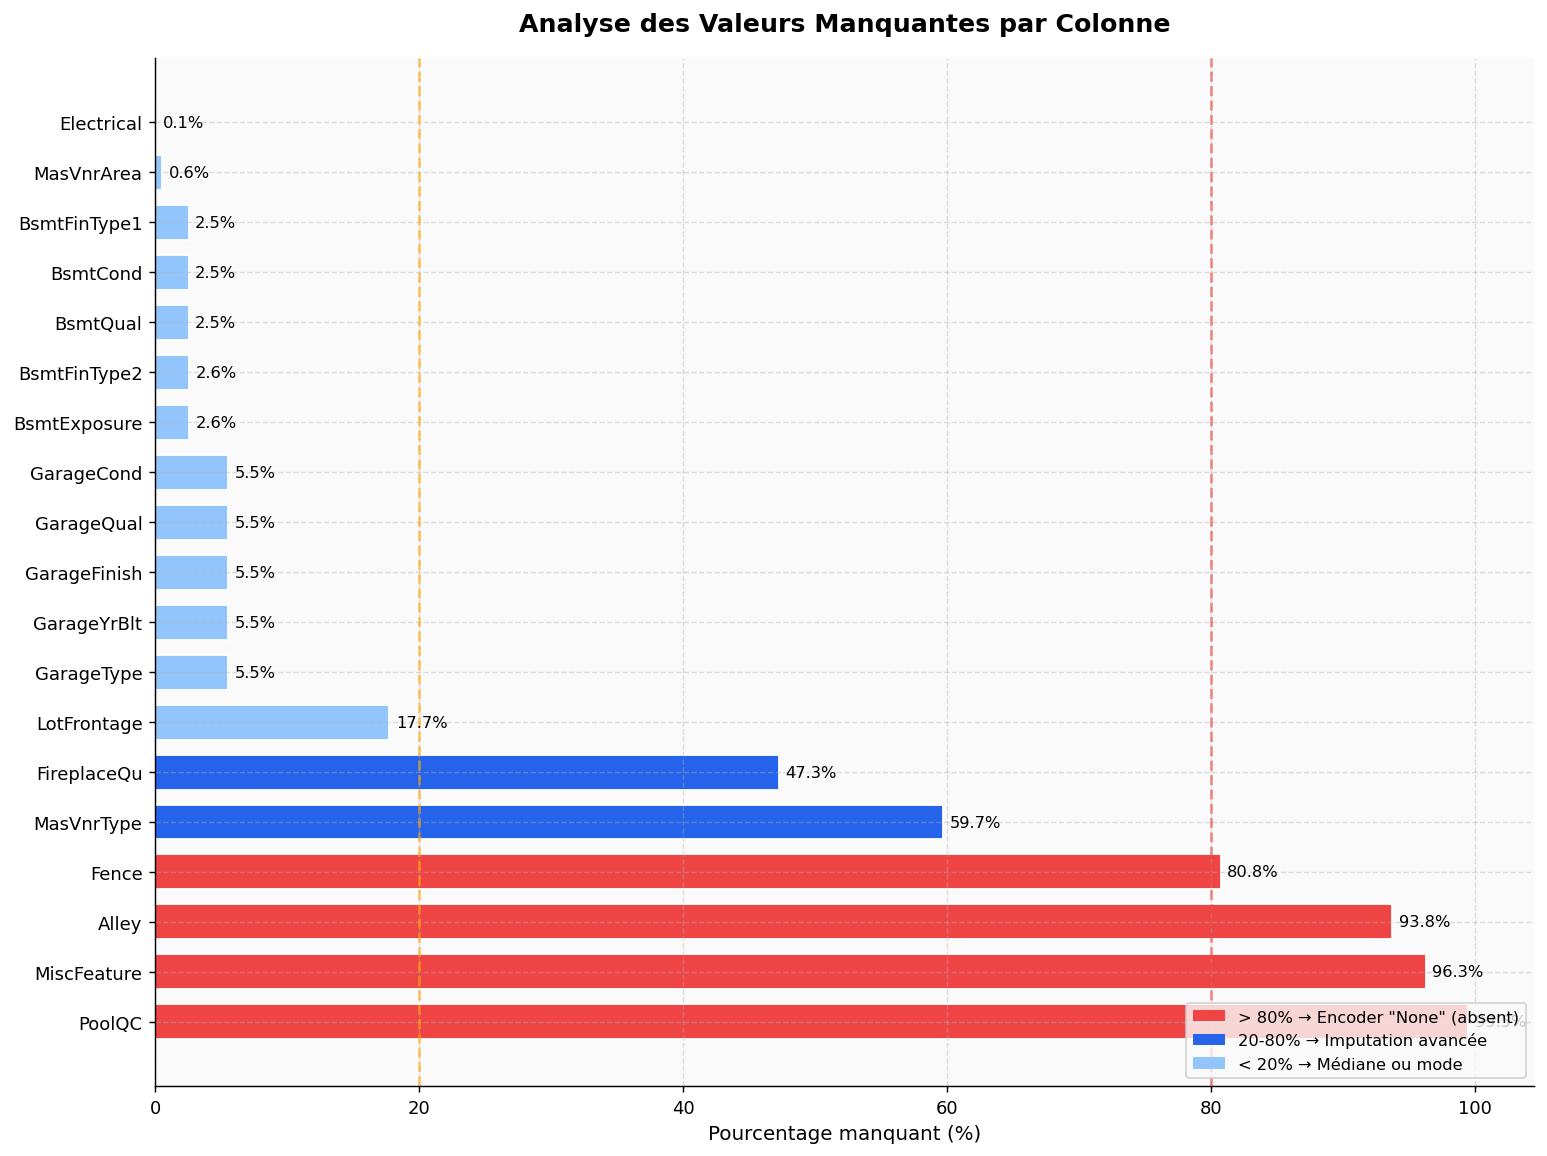

In [6]:
fig, ax = plt.subplots(figsize=(12, 9))

colors = [ACCENT if p > 80 else COLORS[1] if p > 20 else COLORS[3] for p in missing_pct.values]
bars = ax.barh(range(len(missing_pct)), missing_pct.values, color=colors, edgecolor='white', height=0.7)
ax.set_yticks(range(len(missing_pct)))
ax.set_yticklabels(missing_pct.index, fontsize=10)
ax.set_xlabel('Pourcentage manquant (%)', fontsize=11)
ax.set_title('Analyse des Valeurs Manquantes par Colonne', fontsize=14, fontweight='bold', pad=15)
ax.axvline(80, color=ACCENT, linestyle='--', alpha=0.6, label='Seuil 80%')
ax.axvline(20, color='orange', linestyle='--', alpha=0.6, label='Seuil 20%')

for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='500')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=ACCENT, label='> 80% → Encoder "None" (absent)'),
    Patch(facecolor=COLORS[1], label='20-80% → Imputation avancée'),
    Patch(facecolor=COLORS[3], label='< 20% → Médiane ou mode'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../data/fig_02_missing_values.png', bbox_inches='tight', dpi=150)
plt.show()


## 5. Variables Numériques — Distributions & Corrélations <a id='5'></a>

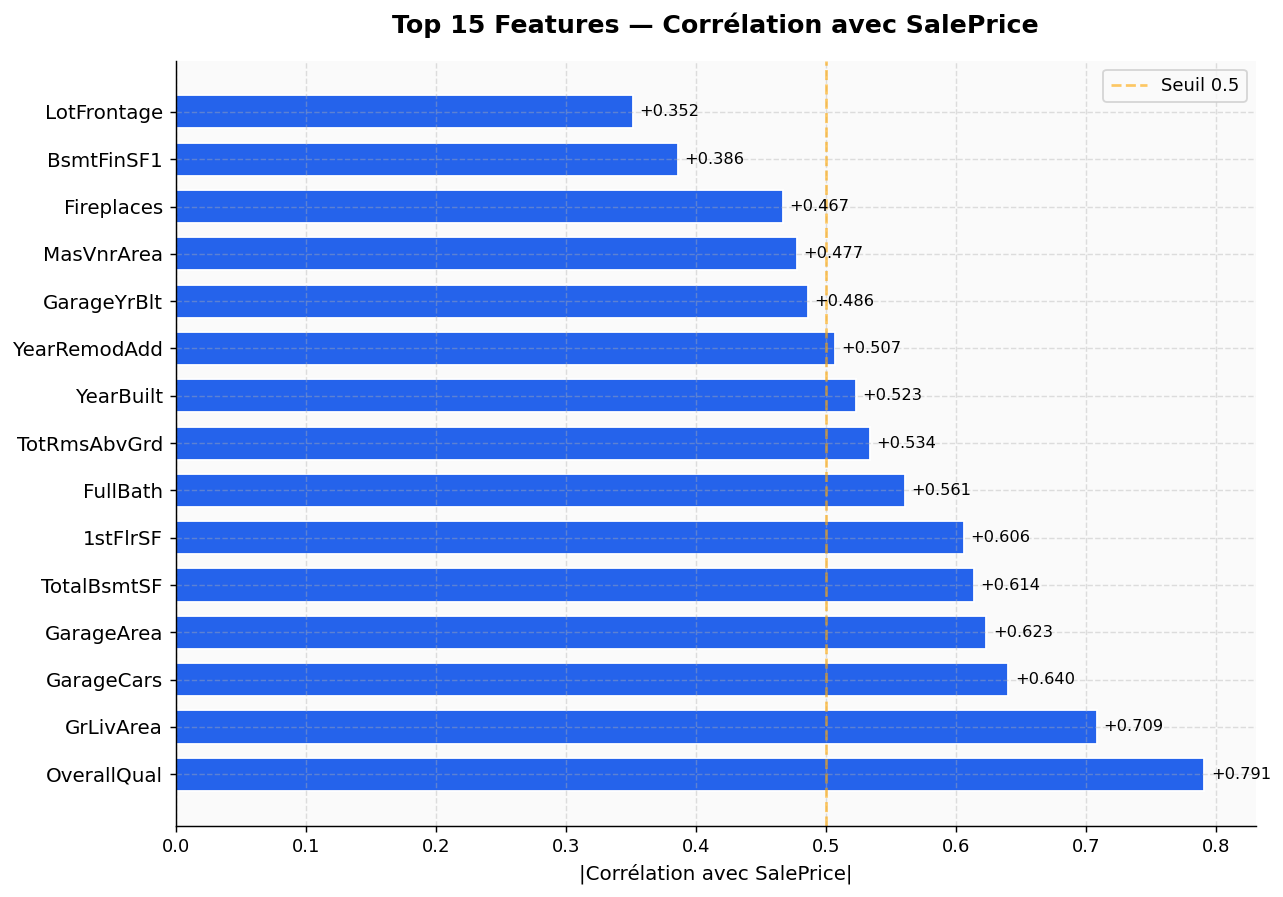

Top 10 features les plus corrélées avec SalePrice :
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101


In [7]:
# Corrélations avec SalePrice
num_cols_clean = [c for c in num_cols if c not in ['Id', 'SalePrice']]
corr = train[num_cols_clean + ['SalePrice']].corr()['SalePrice'].drop('SalePrice')
corr_abs = corr.abs().sort_values(ascending=False)
top15 = corr_abs.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = [COLORS[1] if corr[c] > 0 else ACCENT for c in top15.index]
bars = ax.barh(range(len(top15)), top15.values, color=bar_colors, edgecolor='white', height=0.7)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15.index, fontsize=11)
ax.set_xlabel('|Corrélation avec SalePrice|', fontsize=11)
ax.set_title('Top 15 Features — Corrélation avec SalePrice', fontsize=14, fontweight='bold', pad=15)
ax.axvline(0.5, color='orange', linestyle='--', alpha=0.6, label='Seuil 0.5')
ax.legend(fontsize=10)

for bar, val, col in zip(bars, top15.values, top15.index):
    sign = '+' if corr[col] > 0 else '-'
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{sign}{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/fig_03_correlations.png', bbox_inches='tight', dpi=150)
plt.show()
print('Top 10 features les plus corrélées avec SalePrice :')
print(corr.abs().sort_values(ascending=False).head(10).to_string())


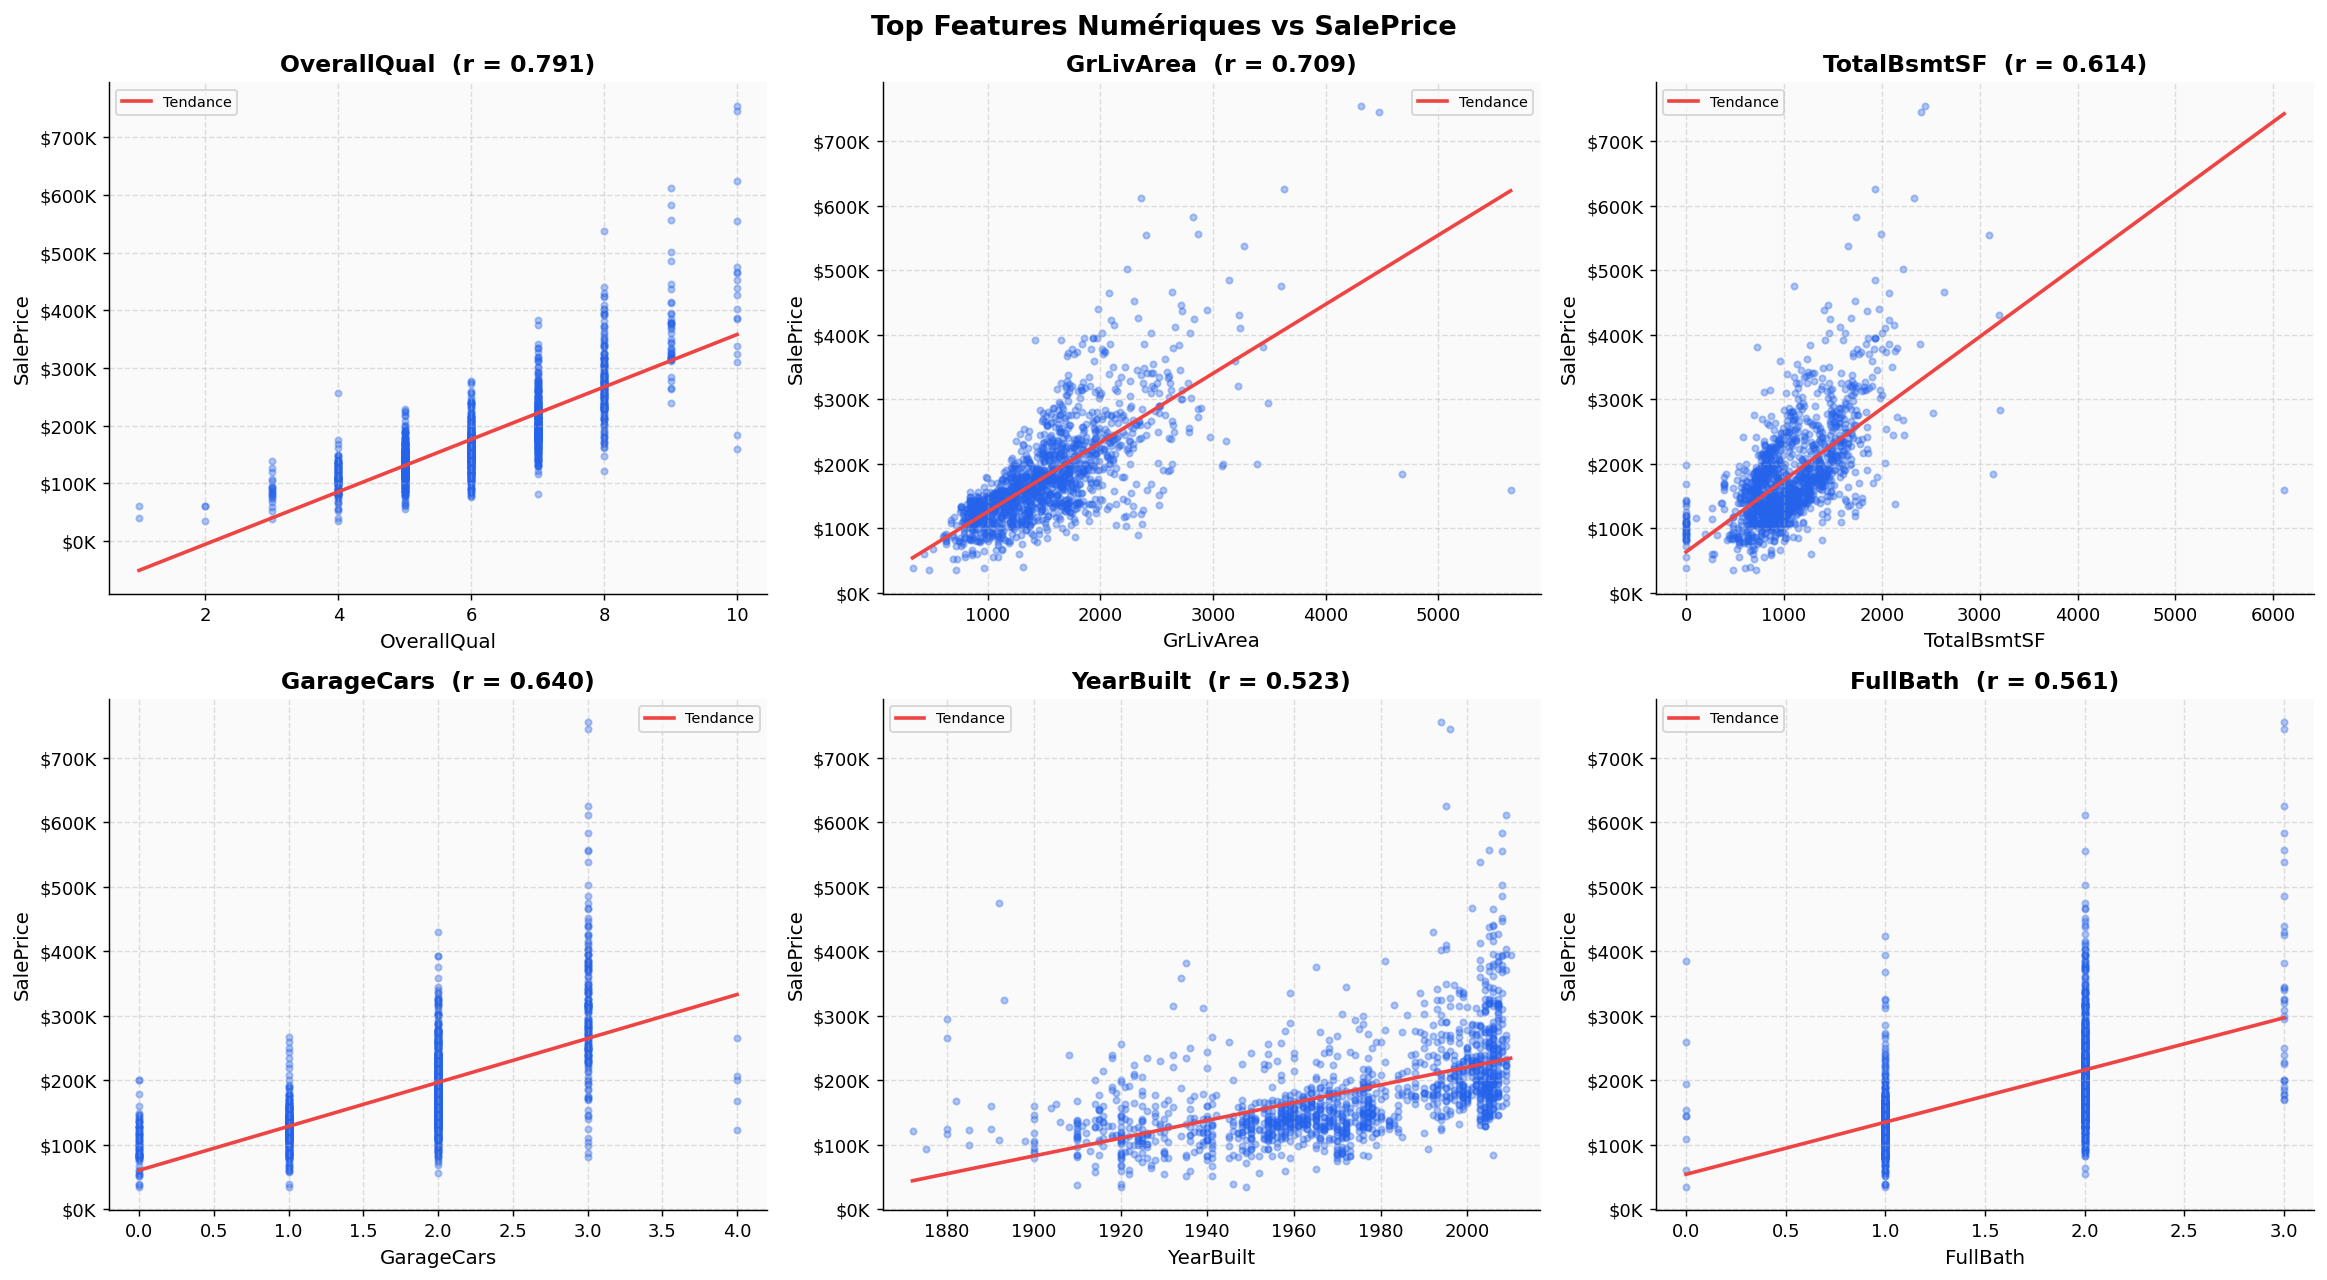

In [8]:
# Scatter plots Top 6 features
top6 = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Top Features Numériques vs SalePrice', fontsize=15, fontweight='bold')

for ax, col in zip(axes.flatten(), top6):
    data = train[[col, 'SalePrice']].dropna()
    ax.scatter(data[col], data['SalePrice'], alpha=0.35, color=COLORS[1], s=12)
    # Ligne de tendance
    z = np.polyfit(data[col], data['SalePrice'], 1)
    p = np.poly1d(z)
    x_sorted = np.sort(data[col])
    ax.plot(x_sorted, p(x_sorted), color=ACCENT, linewidth=2, label='Tendance')
    r = data[col].corr(data['SalePrice'])
    ax.set_title(f'{col}  (r = {r:.3f})', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('SalePrice')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/fig_04_scatter_top_features.png', bbox_inches='tight', dpi=150)
plt.show()


## 6. Variables Catégorielles <a id='6'></a>

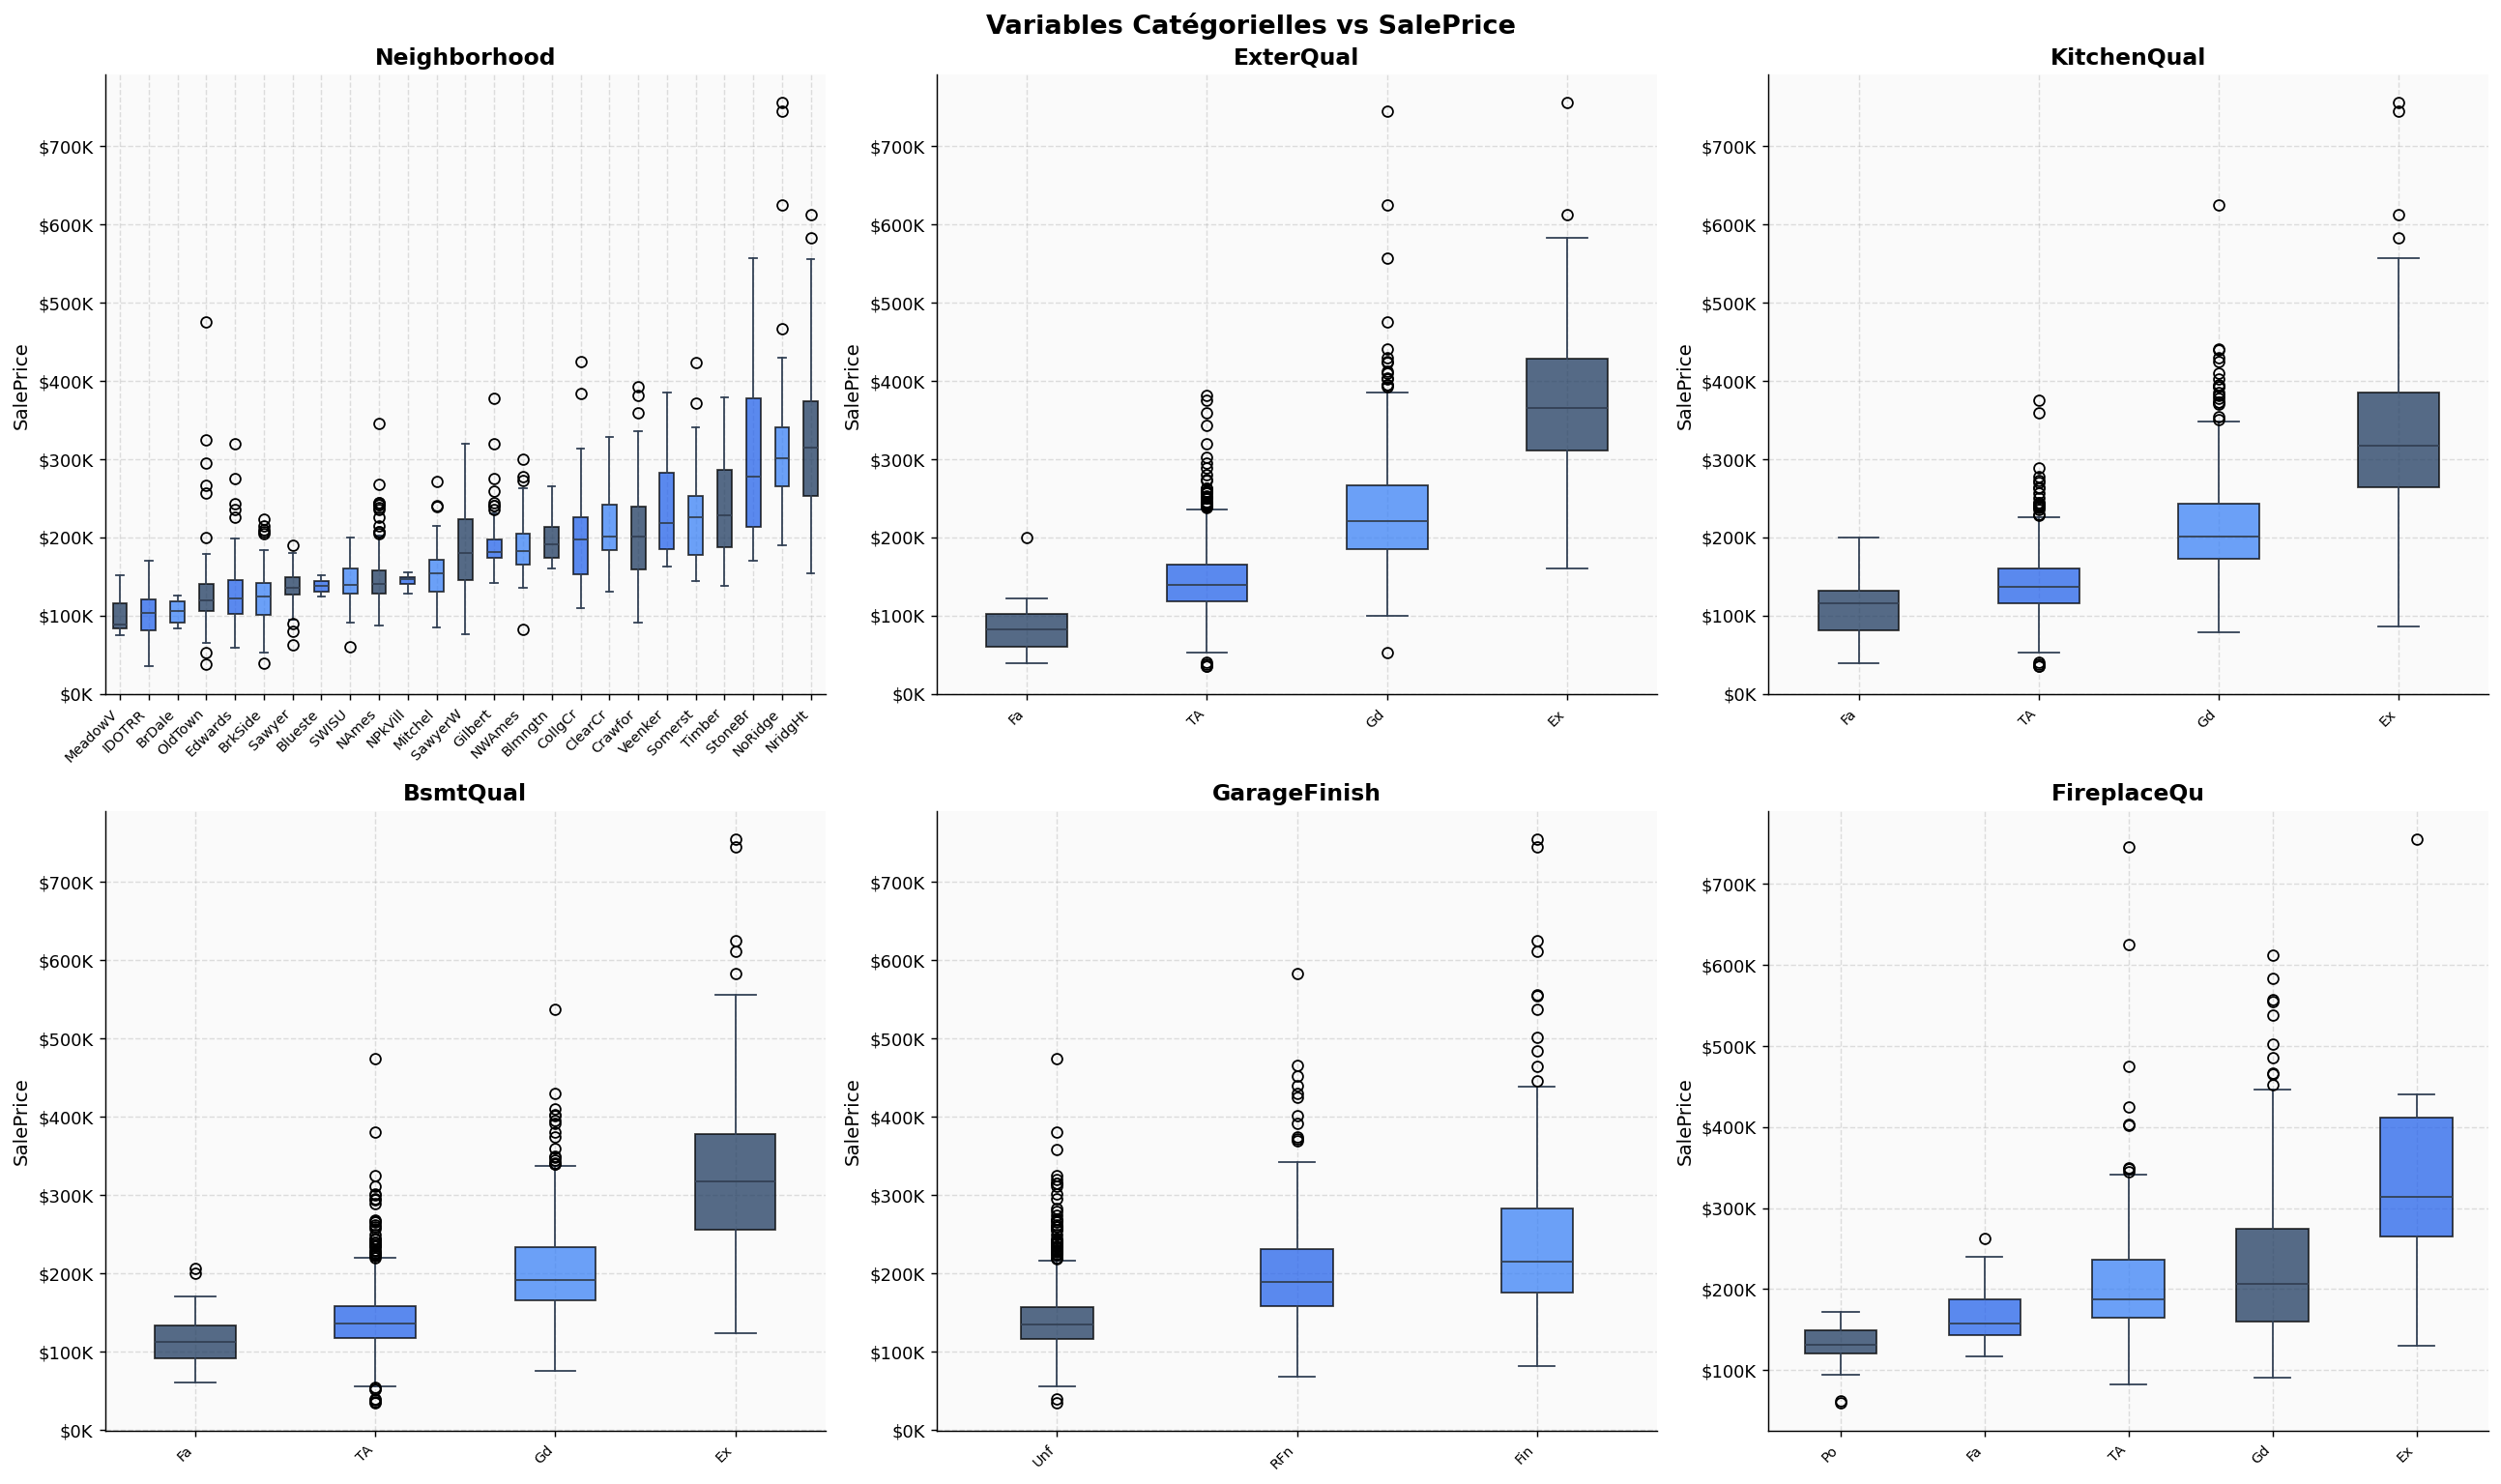

In [9]:
top_cat = ['Neighborhood', 'ExterQual', 'KitchenQual', 'BsmtQual', 'GarageFinish', 'FireplaceQu']
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Variables Catégorielles vs SalePrice', fontsize=15, fontweight='bold')

for ax, col in zip(axes.flatten(), top_cat):
    order = train.groupby(col)['SalePrice'].median().sort_values().index
    data_plot = [train[train[col] == cat]['SalePrice'].dropna().values for cat in order]
    bp = ax.boxplot(data_plot, patch_artist=True, vert=True)
    palette = sns.color_palette(COLORS[:3] * 10, len(order))
    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    for element in ['whiskers', 'fliers', 'means', 'medians', 'caps']:
        plt.setp(bp[element], color='#334155')
    ax.set_xticklabels(order, rotation=45, ha='right', fontsize=8)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('SalePrice')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('../data/fig_05_categorical_features.png', bbox_inches='tight', dpi=150)
plt.show()


## 7. Matrice de Corrélation <a id='7'></a>

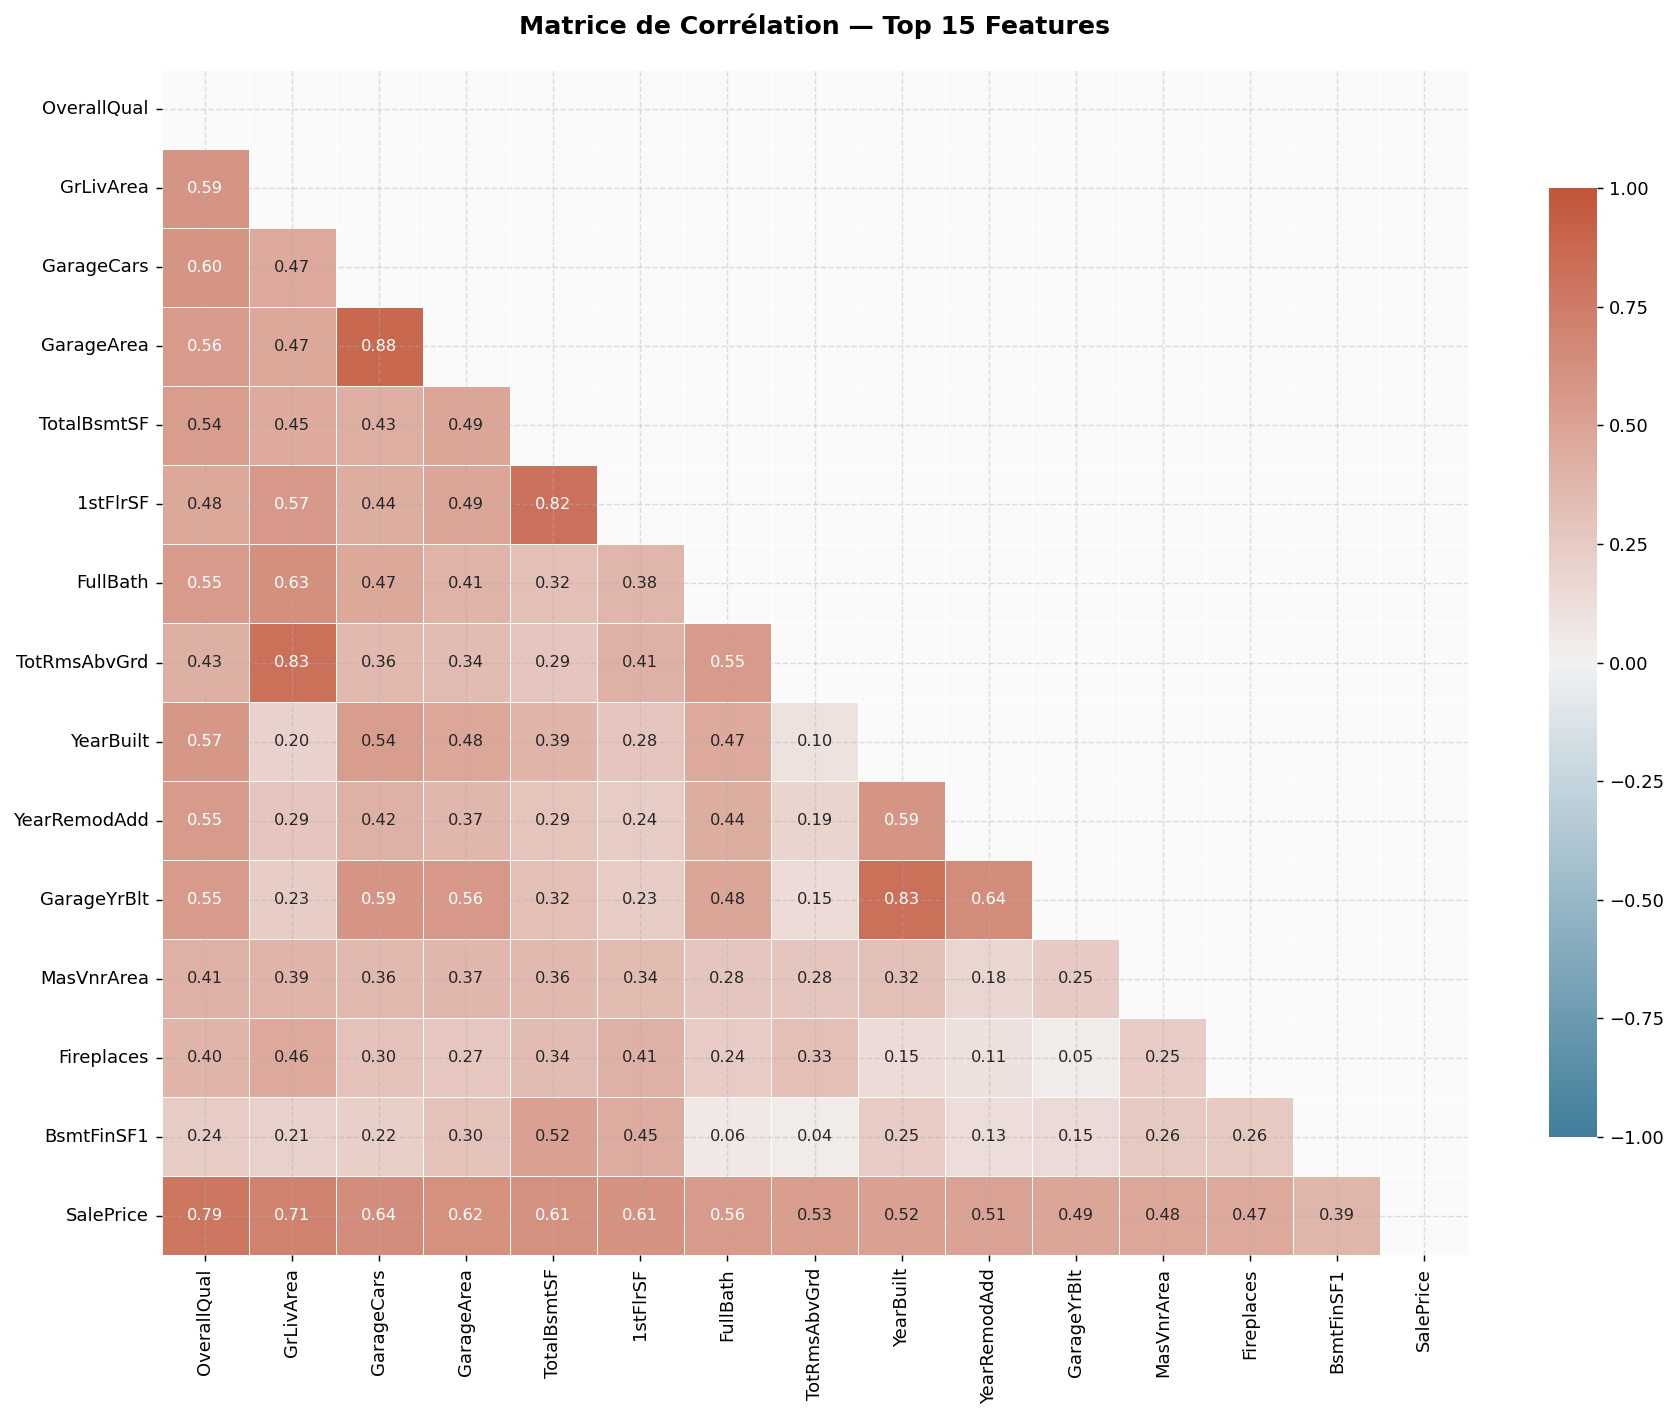

In [10]:
top15_cols = list(corr_abs.head(14).index) + ['SalePrice']
corr_matrix = train[top15_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    cmap=cmap, center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Matrice de Corrélation — Top 15 Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../data/fig_06_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()


## 8. Synthèse & Insights Clés 🎯 <a id='8'></a>

### Résumé des Observations

| # | Insight | Impact |
|---|---------|--------|
| 1 | **SalePrice est skewed** → log1p indispensable | Améliore tous les modèles linéaires |
| 2 | **OverallQual** (r=0.79) = feature #1 | La qualité perçue > la surface |
| 3 | **TotalBsmtSF, 1stFlrSF, GrLivArea** très corrélées | Créer TotalSF = somme |
| 4 | **YearBuilt** important → HouseAge à créer | Les maisons récentes valent plus |
| 5 | **NaN dans PoolQC/Alley/Fence** = absence de feature | Encoder 'None', pas d'imputation |
| 6 | **Neighborhood** très discriminant | Encodage ordinal ou target encoding |

### Actions pour la Modélisation

- `y = np.log1p(train['SalePrice'])`
- Créer : `TotalSF`, `HouseAge`, `TotalBathrooms`, `HasPool`, `HasGarage`
- Encoder les qualités : Ex→5, Gd→4, TA→3, Fa→2, Po→1, None→0
- One-Hot Encoding des catégories nominales
- StandardScaler avant les modèles linéaires
